<a href="https://colab.research.google.com/github/alvarozrd/galaxy-rng-experiment/blob/main/RF_galaxies_PRNGs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

try:
  df_raw = pd.read_csv("galaxies.csv")
except FileNotFoundError:
  print("Arquivo não encontrado...")

In [2]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv('galaxies.csv')
print(df.head(5))
total_linhas = len(df)
print(total_linhas)



   sequentialid  type        gg       m20        cc        aa  sersic_n_gim2d  \
0       87785.0   2.0 -0.178659  0.408056  0.195886 -0.090374       -0.476385   
1       87789.0   2.0  0.542650 -0.742287  0.370185 -0.287801        0.546606   
2       87792.0   2.0  0.984253 -1.223489  1.186458  0.262630        1.562971   
3       87794.0   1.0  1.775592 -1.264211  1.249540 -0.148394        2.043435   
4       87795.0   2.0  0.319965 -0.831671  0.811909  0.518061        0.831674   

   ell_gim2d   r_gim2d  
0   1.510386  0.014649  
1   1.602553 -0.936228  
2   0.707001 -0.536047  
3   0.158608 -0.770333  
4   0.879145 -0.150464  
34874


In [4]:
dataset_rf = df.drop(columns = ["type"])

types = df["type"]

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    dataset_rf,
    types,
    test_size=0.15,
    random_state=57,
    stratify=types
)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=57,
    stratify=y_temp
)

In [7]:
print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

Treino: 24410
Validação: 5232
Teste: 5232


In [9]:
total = len(dataset_rf)

print(f"Treino: {100*len(X_train)/total:.2f}%")
print(f"Validação: {100*len(X_val)/total:.2f}%")
print(f"Teste: {100*len(X_test)/total:.2f}%")

Treino: 69.99%
Validação: 15.00%
Teste: 15.00%


In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [24]:
from numpy.random import PCG64, SFC64, MT19937

generator1=PCG64(seed=57)
generator2=SFC64(seed=57)
generator3=MT19937(seed=57)

In [25]:
gen1 = np.random.RandomState(generator1)
gen2 = np.random.RandomState(generator2)
gen3 = np.random.RandomState(generator3)

In [26]:
from sklearn.ensemble import RandomForestClassifier

randomforest = RandomForestClassifier(
    n_estimators=101,
    criterion="gini",
    max_features="sqrt",
    max_depth=25,
    random_state=gen1,
    class_weight="balanced"
)

scores = cross_val_score(
    randomforest,
    X_train,
    y_train,
    cv=7,
    scoring="accuracy"
)

In [27]:
randomforest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=25, n_estimators=101,
                       random_state=RandomState(PCG64) at 0x7D62E372E540)

In [28]:
#ajuste
y_val_pred = randomforest.predict(X_val)

In [29]:
from sklearn.metrics import accuracy_score

acc_val = accuracy_score(y_val, y_val_pred)

print(f"Acurácia (Validação): {acc_val:.4f}")

Acurácia (Validação): 0.9396


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred
    )
)

              precision    recall  f1-score   support

         1.0       0.85      0.78      0.82       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.86      0.88       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.88      5232
weighted avg       0.94      0.94      0.94      5232



In [31]:
##salvar os dados do relatório em pd

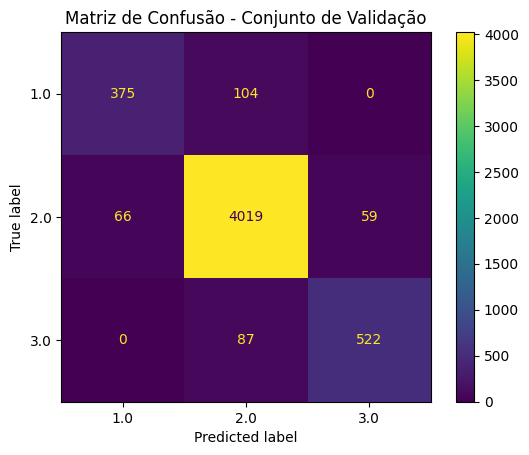

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusão
cm = confusion_matrix(y_val, y_val_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=randomforest.classes_
)

disp.plot()

plt.title("Matriz de Confusão - Conjunto de Validação")
plt.show()

In [33]:
y_test_pred = randomforest.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

acc_test = accuracy_score(y_test, y_test_pred)

print(f"Acurácia (Teste): {acc_test:.4f}")

Acurácia (Teste): 0.9396


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

         1.0       0.85      0.81      0.83       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.83      0.87       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.89      5232
weighted avg       0.94      0.94      0.94      5232



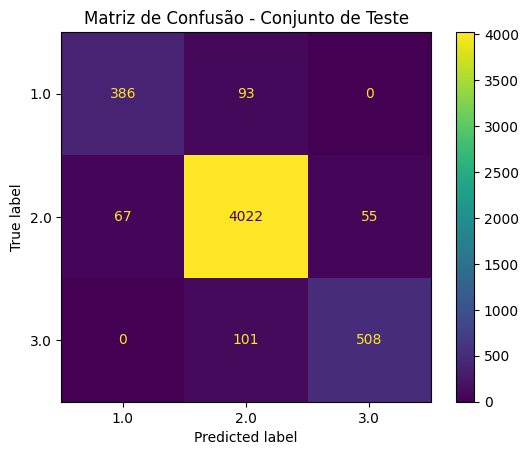

In [36]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=randomforest.classes_
)

disp.plot()
plt.title("Matriz de Confusão - Conjunto de Teste")
plt.show()

In [ ]:
## 2º GERADOR

In [37]:
randomforest = RandomForestClassifier(
    n_estimators=101,
    criterion="gini",
    max_features="sqrt",
    max_depth=25,
    random_state=gen2,
    class_weight="balanced"
)

scores = cross_val_score(
    randomforest,
    X_train,
    y_train,
    cv=7,
    scoring="accuracy"
)

In [38]:
randomforest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=25, n_estimators=101,
                       random_state=RandomState(SFC64) at 0x7D62E372E740)

In [39]:
#ajuste
y_val_pred = randomforest.predict(X_val)

In [40]:
from sklearn.metrics import accuracy_score

acc_val = accuracy_score(y_val, y_val_pred)

print(f"Acurácia (Validação): {acc_val:.4f}")

Acurácia (Validação): 0.9386


In [41]:
y_test_pred = randomforest.predict(X_test)

In [42]:
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

         1.0       0.85      0.81      0.83       479
         2.0       0.96      0.97      0.96      4144
         3.0       0.89      0.84      0.87       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.89      5232
weighted avg       0.94      0.94      0.94      5232



In [43]:
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Acurácia (Teste): {acc_test:.4f}")

Acurácia (Teste): 0.9390


In [ ]:
##3º Gerador

In [44]:
randomforest = RandomForestClassifier(
    n_estimators=101,
    criterion="gini",
    max_features="sqrt",
    max_depth=25,
    random_state=gen3,
    class_weight="balanced"
)

scores = cross_val_score(
    randomforest,
    X_train,
    y_train,
    cv=7,
    scoring="accuracy"
)

In [45]:
randomforest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=25, n_estimators=101,
                       random_state=RandomState(MT19937) at 0x7D62E372E840)

In [46]:
#ajuste
y_val_pred = randomforest.predict(X_val)

In [47]:
from sklearn.metrics import accuracy_score

acc_val = accuracy_score(y_val, y_val_pred)

print(f"Acurácia (Validação): {acc_val:.4f}")

Acurácia (Validação): 0.9404


In [48]:
y_test_pred = randomforest.predict(X_test)

In [49]:
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

         1.0       0.84      0.79      0.82       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.83      0.86       609

    accuracy                           0.94      5232
   macro avg       0.90      0.86      0.88      5232
weighted avg       0.94      0.94      0.94      5232

